# Question 4


Build a spam classifier
- Download examples of spam and ham from Apache SpamAssasin's public datasets(https://homl.info/spamassasin)
- Unzip the datasets and familiarize yourself with the data format.
- Split the data intoa training set and a test set.
- Write a data preparation pipeline to convert each email into a feature vector. The preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, “Hello,” “how,” “are,” “you,” then the email “Hello you Hello Hello you” would be converted into a vector [1, 0, 0, 1] (meaning [“Hello” is present, “how” is absent, “are” is absent, “you” is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word. You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with “URL,” replace all numbers with “NUMBER,” or even perform stemming (i.e., trim off word endings; there are Python libraries available to do this).
- Finally, try out several classifiers and build a great spam classifier, with both high recall and high precision.

## Download and Partition the data
- Download examples of spam and ham from Apache SpamAssasin's public datasets(https://homl.info/spamassasin)
- Unzip the datasets and familiarize yourself with the data format.
- Split the data intoa training set and a test set.

### Download and Unzip data

In [135]:
import tarfile 
from pathlib import Path
import urllib.request


def fetch_spam_data():
    spam_root = "http://spamassassin.apache.org/old/publiccorpus/"
    ham_url = spam_root + "20030228_easy_ham.tar.bz2"
    spam_url = spam_root + "20030228_spam.tar.bz2"

    spam_path = Path() / "datasets" / "Spam"
    spam_path.mkdir(parents=True, exist_ok=True)

    for dir_name, tar_name, url in (("easy_ham", "ham", ham_url),
                                    ("sppam", "spam", spam_url)):
        if not (spam_path / dir_name).is_dir():
            path = (spam_path / tar_name).with_suffix(".tar.bz2")
            print("Downloading", path)
            urllib.request.urlretrieve(url, path)
            tar_bz2_file = tarfile.open(path)
            tar_bz2_file.extractall(path=spam_path)
            tar_bz2_file.close()
    return [spam_path / dir_name for dir_name in ("easy_ham", "spam")]
        

You can read more about the dataset from the README here: https://spamassassin.apache.org/old/publiccorpus/readme.html. The part I care about at the moment is below (taken from the README) 
  - spam: 500 spam messages, all received from non-spam-trap sources.
  - easy_ham: 2500 non-spam messages.  These are typically quite easy to
    differentiate from spam, since they frequently do not contain any spammish
    signatures (like HTML etc).
  - hard_ham: 250 non-spam messages which are closer in many respects to
    typical spam: use of HTML, unusual HTML markup, coloured text,
    "spammish-sounding" phrases etc.
  - easy_ham_2: 1400 non-spam messages.  A more recent addition to the set.
  - spam_2: 1397 spam messages.  Again, more recent.

Total count: 6047 messages, with about a 31% spam ratio.

For our purposes we are going to be using the `easy_ham` and the `spam` messages to start with. Once I have a better understanding of them and run a complete task with them, I can try with the entire dataset, including the `hard_ham`.

In [136]:
# Download and unzip the 'easy_ham' and 'spam' messages
# This will download the data to './datasets' (in the same folder)
nspam_path, spam_path = fetch_spam_data()

/var/folders/47/4h44pnmn5yz4hcgb9v6gx4rr0000gn/T/ipykernel_42118/1861757092.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_bz2_file.extractall(path=spam_path)


In [137]:
nspam_path

PosixPath('datasets/Spam/easy_ham')

In [138]:
spam_path

PosixPath('datasets/Spam/spam')

### Partition the data into the Train and Test set.

In [139]:
from pathlib import PosixPath
import pandas as pd

# What do we need to do here?
# The downloaded messsages are stored in two separate paths one for spam and the other for normal message.
# What we need to do is:
#   1) Read all the file names from the directories
#   2) Assign each file with a flag `is_spam` and assign it appropriately for each message type
#   3) Shuffle and split the message set into a train and test split (I will be using an 80-20 split)

def list_message(message_path: PosixPath, is_spam: bool):
    return pd.DataFrame(data=[(m, is_spam) for m in message_path.iterdir()], columns=["message_path", "is_spam"])

nspam_path_df = list_message(nspam_path, False)
spam_path_df = list_message(spam_path, True)

messages_path_df = pd.concat([nspam_path_df, spam_path_df])

In [140]:
messages_path_df.head()

,message_path,is_spam
0,datasets/Spam/easy_ham/00769.25bf9a767b5db0ed9...,False
1,datasets/Spam/easy_ham/01074.8590d61ac0aeeadb5...,False
2,datasets/Spam/easy_ham/02479.14365bcad3a60fcf2...,False
3,datasets/Spam/easy_ham/01417.ce7b07a2114218dba...,False
4,datasets/Spam/easy_ham/00357.d559b71616f64ba1d...,False


In [141]:
messages_path_df.describe()

,message_path,is_spam
count,3002,3002
unique,3002,2
top,datasets/Spam/easy_ham/00769.25bf9a767b5db0ed9...,False
freq,1,2501


In [142]:
import numpy as np
from sklearn.model_selection import train_test_split

# Shuffle and split. `train_test_split` shuffles the set by default via the `shuffle` argument.
X_train, X_test, y_train, y_test = train_test_split(messages_path_df["message_path"], messages_path_df["is_spam"], test_size=0.20, random_state=137)

In [143]:
print(f"We now have a train set of size X:{len(X_train)}, y: {len(y_train)}")
print(f"We also have a test set of size X:{len(X_test)}, y: {len(y_test)}")

We now have a train set of size X:2401, y: 2401
We also have a test set of size X:601, y: 601


## Data Exploration
Now that we have downloaded and split the data we need to look at our train set to understand the data we actually downloade: What is in the file? What are the specific information we have? What do examples of the spam email look like? What do examples of a regular email look like in contrast?

To that end, we should:
- Read an example of each type of email and review it.
- Check what keys the email has.

In [144]:
train_df = pd.DataFrame(data={"message_path": X_train, "is_spam": y_train})

is_spam = train_df["is_spam"]
example_nspam_path = np.random.choice(train_df[~is_spam]["message_path"])
example_spam_path = np.random.choice(train_df[is_spam]["message_path"])

In [145]:
def read_message(path: str):
    return 

nspam_email = Path(example_nspam_path).read_text()
spam_email = Path(example_spam_path).read_text()

Non-Spam Email Example:

In [146]:
print(nspam_email)

From sentto-2242572-56021-1034080421-zzzz=spamassassin.taint.org@returns.groups.yahoo.com  Tue Oct  8 14:40:28 2002
Return-Path: <sentto-2242572-56021-1034080421-zzzz=spamassassin.taint.org@returns.groups.yahoo.com>
Delivered-To: zzzz@localhost.spamassassin.taint.org
Received: from localhost (jalapeno [127.0.0.1])
	by spamassassin.taint.org (Postfix) with ESMTP id 25B6416F17
	for <zzzz@localhost>; Tue,  8 Oct 2002 14:39:49 +0100 (IST)
Received: from jalapeno [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Tue, 08 Oct 2002 14:39:49 +0100 (IST)
Received: from n38.grp.scd.yahoo.com (n38.grp.scd.yahoo.com
    [66.218.66.106]) by dogma.slashnull.org (8.11.6/8.11.6) with SMTP id
    g98CX0K15512 for <zzzz@spamassassin.taint.org>; Tue, 8 Oct 2002 13:33:00 +0100
X-Egroups-Return: sentto-2242572-56021-1034080421-zzzz=spamassassin.taint.org@returns.groups.yahoo.com
Received: from [66.218.67.199] by n38.grp.scd.yahoo.com with NNFMP;
    08 Oct 2002 12:33:4

Spam Email Example:

In [147]:
print(spam_email)

From loki@mymail.dk  Wed Aug 28 18:06:03 2002
Return-Path: <loki@mymail.dk>
Delivered-To: zzzz@localhost.spamassassin.taint.org
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.spamassassin.taint.org (Postfix) with ESMTP id C0C6343F99
	for <zzzz@localhost>; Wed, 28 Aug 2002 12:46:32 -0400 (EDT)
Received: from mail.webnote.net [193.120.211.219]
	by localhost with POP3 (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Wed, 28 Aug 2002 17:46:32 +0100 (IST)
Received: from mymail.dk ([67.36.72.129])
	by webnote.net (8.9.3/8.9.3) with SMTP id RAA05587;
	Wed, 28 Aug 2002 17:39:48 +0100
Date: Wed, 28 Aug 2002 17:39:48 +0100
From: loki@mymail.dk
Reply-To: <loki@mymail.dk>
Message-ID: <008e76e11ecb$1525a3d3$3bd32da2@okgpnw>
To: dsi3@yahoo.com
Subject: WORK FROM HOME.  WE ARE HIRING
MiME-Version: 1.0
Content-Type: text/plain;
	charset="iso-8859-1"
X-Priority: 3 (Normal)
X-MSMail-Priority: Normal
X-Mailer: eGroups Message Poster
Importance: Normal
Content-Transfer-Encoding: 8bit

Honestly even some of the non-spam emails look like spam to me lool. Double checked my logic just to make sure I wasn't mis-assigning the spam flag. But we do build an intuition for them after reviewing a few examples.

One additional thing: the emails (of both type) have a similar "key-value" pair format. We should be able to parse them and extract information from them in a more structured format. There are pre-existing libraries to read email message. Let's use the `email` library for this.

In [148]:
from typing import List, AnyStr

from bs4 import BeautifulSoup
import email
from email.message import Message


def read_email(path: PosixPath) -> Message:
    with open(path, 'rb') as f:
        return email.message_from_bytes(f.read())


def strip_html(html: AnyStr) -> AnyStr:
    return BeautifulSoup(html, "html.parser").get_text()


def get_emails_as_df(email_paths: List[AnyStr]) -> pd.DataFrame:

    email_rows = []
    for email_path in email_paths:
        message = read_email(email_path) 
        email_row = {"message_path": email_path}

        for header in message.keys():
            # Some values aren't strings.
            list_of_values = message.get_all(header)
            email_row[header] = ",".join(map(str, list_of_values))
        email_rows.append(email_row)
    
    return pd.DataFrame(data=email_rows)


def get_email_body(msg: Message) -> AnyStr:
    """
    GENERATED THIS USING AN AI AGENT.
    """
    if msg.is_multipart():
        for part in msg.walk():
            content_type = part.get_content_type()
            content_disposition = str(part.get("Content-Disposition"))

            if content_type == "text/plain" and "attachment" not in content_disposition:
                return part.get_payload(decode=True).decode(part.get_content_charset() or 'utf-8', errors='replace')
            elif content_type == "text/html" and "attachment" not in content_disposition:
                html = part.get_payload(decode=True).decode(part.get_content_charset() or 'utf-8', errors='replace')
                return strip_html(html)
    else:
        charset = msg.get_content_charset()
        if charset in ("default_charset", "default", "unknown-8bit"):
            charset = None
        return msg.get_payload(decode=True).decode(charset or 'utf-8', errors='replace')


msg = read_email(example_nspam_path)


In [149]:
email_df = get_emails_as_df(train_df["message_path"].tolist())

In [150]:
email_df.describe()

,message_path,Return-Path,Delivered-To,Received,From,To,Subject,Message-Id,Mail-Followup-To,References,...,X-Viruschecked,X-Env-Sender,X-MSG-Ref,X-Vipmail-Smtpmailfrom,X-Vopfilter-Ip,X-Epoch,X-Sasl-Enc,X-Pmflags,X-Uidl,X-RCPT-To
count,2401,2396,2269,2289,2400,2274,2400,2231,40,627,...,1,1,1,1,1,2,2,1,1,1
unique,2401,467,33,2289,790,558,1738,2231,31,563,...,1,1,1,1,1,2,2,1,1,1
top,datasets/Spam/easy_ham/01447.98e4b20ceb192594e...,<fork-admin@xent.com>,yyyy@localhost.spamassassin.taint.org,from localhost (jalapeno [127.0.0.1])\n\tby jm...,boingboing <rssfeeds@spamassassin.taint.org>,yyyy@spamassassin.taint.org,[Spambayes] test sets?,<20020906180419.GA14739@iww.netfr.alcatel.fr>,ilug@linux.ie,<20020201150022.B11472@cs.helsinki.fi>\n <2...,...,Checked,ken@tuatha.org,server-5.tower-4.messagelabs.com!1039000939!17975,bsobel@vipmail.com,198.6.50.33,1030294257,P8OwrRaDs2VlLKfQnqm1Zg,10326341.10,10293217_192832.222,<rpm-zzzlist@freshrpms.net>
freq,1,532,826,1,88,500,24,1,4,3,...,1,1,1,1,1,1,1,1,1,1


In [151]:
# We will probably skip these headers as we don't have a lot of information in them.
low_information_columns = email_df.columns[(email_df.nunique() < 500) & (email_df.count() < 2000)]
email_df[low_information_columns]

,Mail-Followup-To,MIME-Version,Content-Disposition,X-Mailer,X-Virus-Scanned,Sender,Errors-To,X-Beenthere,X-Mailman-Version,Precedence,...,X-Viruschecked,X-Env-Sender,X-MSG-Ref,X-Vipmail-Smtpmailfrom,X-Vopfilter-Ip,X-Epoch,X-Sasl-Enc,X-Pmflags,X-Uidl,X-RCPT-To
0,Stephane Lentz <Stephane.Lentz@ansf.alcatel.fr...,1.0,inline,Bogus Notes 5.10.666 (Corporate Release),by amavisd-milter (http://amavis.org/),spamassassin-talk-admin@example.sourceforge.net,spamassassin-talk-admin@example.sourceforge.net,spamassassin-talk@example.sourceforge.net,2.0.9-sf.net,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,eGroups Message Poster,NaN,Membership Adult Club <ib@newafrica.com>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1.0,NaN,Microsoft CDO for Windows 2000,NaN,ilug-admin@linux.ie,ilug-admin@linux.ie,ilug@linux.ie,1.1,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2398,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2399,NaN,1.0,NaN,Sylpheed version 0.8.3claws (GTK+ 1.2.10; i386...,NaN,rpm-zzzlist-admin@freshrpms.net,rpm-zzzlist-admin@freshrpms.net,rpm-zzzlist@freshrpms.net,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
email_information_df = email_df.loc[:, ~email_df.columns.isin(low_information_columns)] # we should include Sender, Reply-To, CC, Bcc, X-Sender, do we need add List-Id too?
email_information_df

,message_path,Return-Path,Delivered-To,Received,From,To,Subject,Message-Id,References,Content-Type,In-Reply-To,Date
0,datasets/Spam/easy_ham/01447.98e4b20ceb192594e...,<spamassassin-talk-admin@example.sourceforge.net>,yyyy@localhost.spamassassin.taint.org,from localhost (jalapeno [127.0.0.1])\n\tby jm...,Stephane Lentz <Stephane.Lentz@ansf.alcatel.fr>,spamassassin-talk@example.sourceforge.net,Re: [SAtalk] Lotus Notes users?,<20020906180419.GA14739@iww.netfr.alcatel.fr>,<3D78E46C.5070101@startechgroup.co.uk>,text/plain; charset=us-ascii,<3D78E46C.5070101@startechgroup.co.uk>,"Fri, 6 Sep 2002 20:04:20 +0200"
1,datasets/Spam/spam/00069.066b1a012235d062a5da7...,<ib@newafrica.com>,zzzz@localhost.spamassassin.taint.org,from localhost (localhost [127.0.0.1])\n\tby p...,Membership Adult Club <ib@newafrica.com>,zzzz@spamassassin.taint.org,Fw: Re: Account For Cum Shots To: zzzz@spamass...,<200208260645.HAA24928@webnote.net>,NaN,"text/plain; charset=""iso-8859-1""",NaN,"Sun, 25 Aug 2002 23:45:07 -0700"
2,datasets/Spam/easy_ham/00776.20cdc88a69e453f1e...,<fork-admin@xent.com>,"yyyy@localhost.spamassassin.taint.org,fork@spa...",from localhost (jalapeno [127.0.0.1])\n\tby jm...,"""R. A. Hettinga"" <rah@shipwright.com>",fork@spamassassin.taint.org,Re: SF Weekly's Ultimate SF Date lineup :-),<p05111a20b9b6c2a2b66f@[66.149.49.6]>,NaN,"text/plain; charset=""us-ascii""",NaN,"Tue, 24 Sep 2002 21:34:55 -0400"
3,datasets/Spam/spam/00020.29725cf331fc21e18a180...,<ilug-admin@linux.ie>,zzzz@localhost.spamassassin.taint.org,from localhost (localhost [127.0.0.1])\n\tby p...,"""FreeLegal Advice"" <jaen@s3.serveimage.com>",<ilug@linux.ie>,[ILUG] Get the Child Support You Deserve ...,<16a78d01c24a14$2d585440$0e06fea9@freeyankeedo...,NaN,"text/plain; charset=""iso-8859-1""",NaN,"Thu, 22 Aug 2002 13:43:24 -0600"
4,datasets/Spam/easy_ham/00659.1217006d88c29f2f9...,<fork-admin@xent.com>,"yyyy@localhost.spamassassin.taint.org,fork@spa...",from localhost (jalapeno [127.0.0.1])\n\tby jm...,Tom <tomwhore@slack.net>,Bill Stoddard <bill@wstoddard.com>,RE: Hanson's Sept 11 message in the National R...,<Pine.BSO.4.44.0209191408190.6296-100000@crank...,NaN,TEXT/PLAIN; charset=US-ASCII,<JHEPKCEMGPKFFDHHDDKDKELKFGAA.bill@wstoddard.com>,"Thu, 19 Sep 2002 14:13:10 -0400 (EDT)"
...,...,...,...,...,...,...,...,...,...,...,...,...
2396,datasets/Spam/easy_ham/00740.aef9889d927eccf01...,<fork-admin@xent.com>,"yyyy@localhost.spamassassin.taint.org,fork@spa...",from localhost (jalapeno [127.0.0.1])\n\tby jm...,Tom <tomwhore@slack.net>,fork@spamassassin.taint.org,Here Come Da Feds,<Pine.BSO.4.44.0209231847230.29230-100000@cran...,NaN,TEXT/PLAIN; charset=US-ASCII,NaN,"Mon, 23 Sep 2002 18:51:16 -0400 (EDT)"
2397,datasets/Spam/easy_ham/02331.20925f3659cfea80b...,<rssfeeds@spamassassin.taint.org>,yyyy@localhost.spamassassin.taint.org,from localhost (jalapeno [127.0.0.1])\n\tby jm...,boingboing <rssfeeds@spamassassin.taint.org>,yyyy@spamassassin.taint.org,"9/11, war in Iraq threaten Disney parks",<200210070800.g9780NK23229@dogma.slashnull.org>,NaN,text/plain; encoding=utf-8,NaN,"Mon, 07 Oct 2002 08:00:23 -0000"
2398,datasets/Spam/easy_ham/00324.ce7f14e25bb864ee4...,<fork-admin@xent.com>,"yyyy@localhost.netnoteinc.com,fork@spamassassi...",from localhost (localhost [127.0.0.1])\n\tby p...,Dan Brickley <danbri@w3.org>,Lucas Gonze <lgonze@panix.com>,Re: The case for spam,<Pine.LNX.4.30.0208221935220.31207-100000@tux....,NaN,TEXT/PLAIN; charset=US-ASCII,<Pine.LNX.4.44.0208221910560.17440-100000@loca...,"Thu, 22 Aug 2002 19:39:45 -0400 (EDT)"
2399,datasets/Spam/easy_ham/01204.023682c9961ab2311...,<rpm-zzzlist-admin@freshrpms.net>,yyyy@localhost.spamassassin.taint.org,from localhost (jalapeno [127.0.0.1])\n\tby jm...,Matthias Saou <matthias@egwn.net>,Hesty P <hestyp@yahoo.com>,Re: ALSA Problem with Null kernel,<20020930225131.5fe5aa07.matthias@egwn.net>,<20020930215046.108ba76f.matthias@egwn.net>\n ...,text/plain; charset=US-ASCII,<20020930203212.61851.qmail@web20512.mail.yaho...,"Mon, 30 Sep

In [153]:
email_df[low_information_columns]

,Mail-Followup-To,MIME-Version,Content-Disposition,X-Mailer,X-Virus-Scanned,Sender,Errors-To,X-Beenthere,X-Mailman-Version,Precedence,...,X-Viruschecked,X-Env-Sender,X-MSG-Ref,X-Vipmail-Smtpmailfrom,X-Vopfilter-Ip,X-Epoch,X-Sasl-Enc,X-Pmflags,X-Uidl,X-RCPT-To
0,Stephane Lentz <Stephane.Lentz@ansf.alcatel.fr...,1.0,inline,Bogus Notes 5.10.666 (Corporate Release),by amavisd-milter (http://amavis.org/),spamassassin-talk-admin@example.sourceforge.net,spamassassin-talk-admin@example.sourceforge.net,spamassassin-talk@example.sourceforge.net,2.0.9-sf.net,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,eGroups Message Poster,NaN,Membership Adult Club <ib@newafrica.com>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1.0,NaN,Microsoft CDO for Windows 2000,NaN,ilug-admin@linux.ie,ilug-admin@linux.ie,ilug@linux.ie,1.1,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2398,NaN,1.0,NaN,NaN,NaN,fork-admin@xent.com,fork-admin@xent.com,fork@spamassassin.taint.org,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2399,NaN,1.0,NaN,Sylpheed version 0.8.3claws (GTK+ 1.2.10; i386...,NaN,rpm-zzzlist-admin@freshrpms.net,rpm-zzzlist-admin@freshrpms.net,rpm-zzzlist@freshrpms.net,2.0.11,bulk,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [154]:
# Let's read all the emails
email_information_df["body"] = email_information_df["message_path"].map(lambda path: get_email_body(read_email(path)))

/var/folders/47/4h44pnmn5yz4hcgb9v6gx4rr0000gn/T/ipykernel_42118/3413614682.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email_information_df["body"] = email_information_df["message_path"].map(lambda path: get_email_body(read_email(path)))


In [155]:
print(email_information_df["body"].iloc[1])
## Lol - definitely spam.

 ##################################################
#                                                #
#                 Adult Club                     #
#           Offers FREE Membership               #
#                                                #
##################################################

>>>>>  INSTANT ACCESS TO ALL SITES NOW
>>>>>  Your User Name And Password is.
>>>>>  User Name: zzzz@spamassassin.taint.org
>>>>>  Password: 1534

3 of the Best Adult Sites on the Internet for FREE!

---------------------------------------

NEWS 08/15/02
With just over 2.9 Million Members that signed up for FREE, Last month
there were 721,184 New
Members. Are you one of them yet???

---------------------------------------

Our Membership FAQ

Q. Why are you offering free access to 3 adult membership sites for
free?
A. I have advertisers that pay me for ad space so you don't have to pay
for membership.

Q. Is it true my membership is for life?
A. Absolutely you'll never have to pay a 

[nltk_data] Downloading package punkt_tab to /Users/noel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


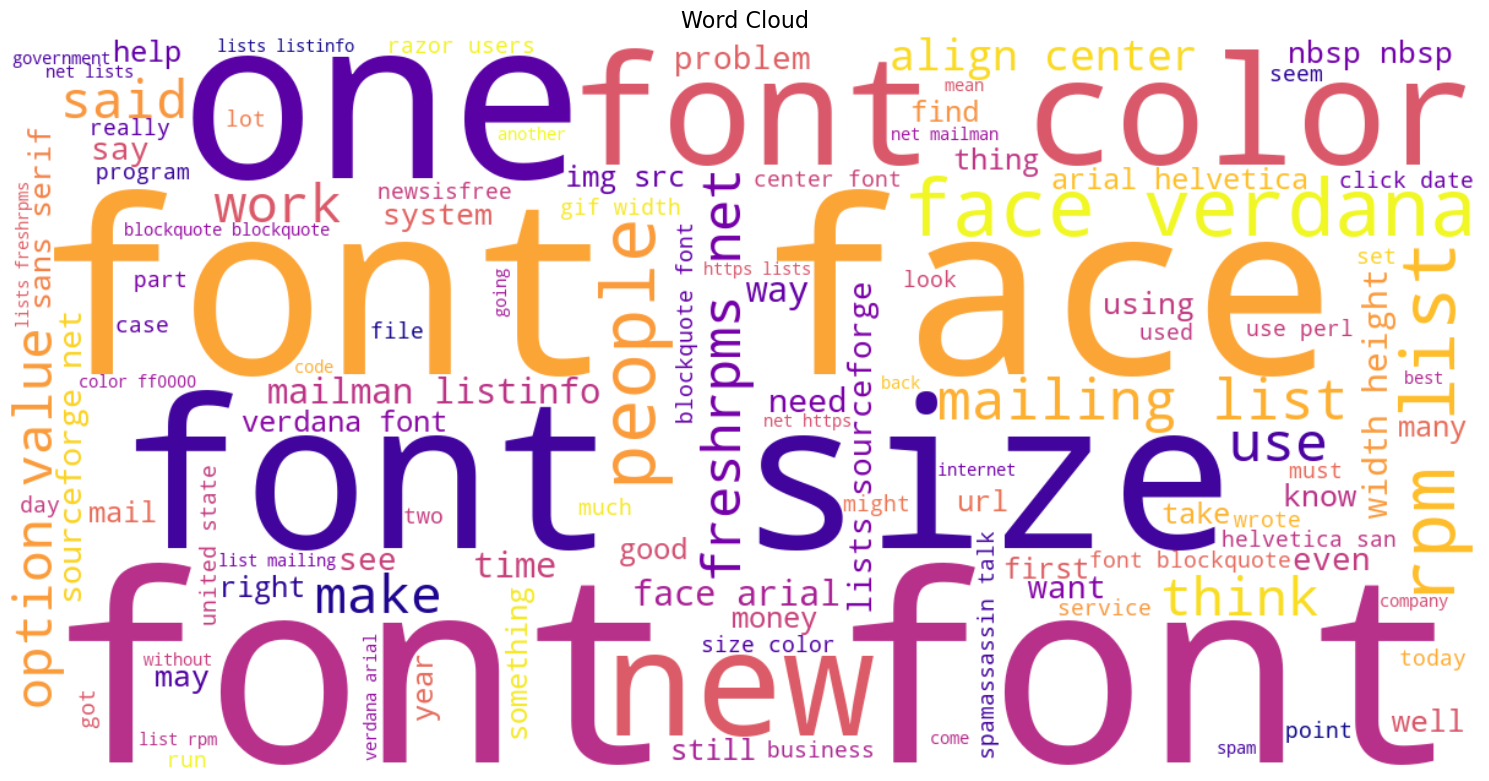

In [156]:
import re
from typing import List

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

nltk.download('punkt_tab')

def create_advanced_word_cloud(all_text: List[str], title: str="Word Cloud"):
    
    # Advanced text cleaning
    text = all_text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
    
    cleaned_text = ' '.join(filtered_words)
    
    ### THANK YOU AI FOR THE MATPLOTLIB CODE.
    wordcloud = WordCloud(
        width=1200, 
        height=600, 
        background_color='white',
        max_words=150,
        colormap='plasma',
        min_font_size=10
    ).generate(cleaned_text)
    
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()


all_text = " ".join(email_information_df["body"].tolist())
create_advanced_word_cloud(all_text)

## Data Pipeline
Now that we have divided our data and have some sense of what our emails look like we need to prepare these emails for our classification models. For this, we need to write a pipeline that makes our messages easily digestible. Fortunatley for us, the excercise gives us some instruction and options on what we might do here so let's try that out.
- Write a data preparation pipeline to convert each email into a feature vector. The preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, “Hello,” “how,” “are,” “you,” then the email “Hello you Hello Hello you” would be converted into a vector [1, 0, 0, 1] (meaning [“Hello” is present, “how” is absent, “are” is absent, “you” is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word. You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with “URL,” replace all numbers with “NUMBER,” or even perform stemming (i.e., trim off word endings; there are Python libraries available to do this).


Our pipeline needs to:
1. Take in the message paths as inputs
2. Read and Parse each message
3. Transform the message into our sparse vector.

To achive (3) i.e. assign the count of each word occurrence to a specific index that represents the word, we need to (beforehand) know all the words that could potentially
exist in our messages (this also would depend on if we would do stemming or trim off word endings) -  we don't have to solve all the problems in one shot. But it's good to
keep in mind. 

**IMPORTANT**: Also, how do we handle words that do not exist in the train set, but do exist in the test set? (Need to read about this).

Question: Also, how do we handle words that do not exist in the train set, but do exist in the test set?
Answer: Based on my reading, the most straightforward solution to this is the introduction of an "UNKNOWN_WORK" to which any words that exist below a certain occurrence count would be assigned. Hence any new words would automatically go under here.

We can implement this, however, I read about the Word2Vec model which can handle this logic and do a little more with respect to the word embeddings. So, rather than just having a counter I'm going to use the Word2Vec model for the embeddings.

In [157]:
import os
import re
from collections import Counter
from email import policy
from email.parser import BytesParser
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def preprocess(
    text,
    lowercase=True,
    remove_punct=True,
    replace_urls=True,
    replace_nums=True,
    stemming=False
):
    # normalize case
    if lowercase:
        text = text.lower()
    # replace URLs with token
    if replace_urls:
        text = re.sub(r'http\S+|www\S+', 'URL', text)
    # replace numbers with token
    if replace_nums:
        text = re.sub(r'\d+', 'NUMBER', text)
    # remove punctuation
    if remove_punct:
        text = re.sub(r'[^\w\s]', '', text)
    # tokenize
    tokens = text.split()
    # stemming
    if stemming:
        tokens = [ps.stem(tok) for tok in tokens]
    return tokens


In [158]:
def safe_decode(content, charset):
    """Safely decode content with fallback encodings"""
    if charset in ('default_charset', 'DEFAULT_CHARSET', 'default', 'unknown-8bit', None):
        # Try common encodings
        for encoding in ['utf-8', 'latin1', 'ascii']:
            try:
                return content.decode(encoding)
            except UnicodeDecodeError:
                continue
        # If all else fails, use latin1 (it can decode any byte sequence)
        return content.decode('latin1', errors='replace')
    
    # Try the specified charset
    try:
        return content.decode(charset)
    except (UnicodeDecodeError, LookupError):
        # If specified charset fails, fall back to latin1
        return content.decode('latin1', errors='replace')

def extract_text_from_email(path, include_headers=False):
    """Read raw email and return text (headers + body or just body)."""
    with open(path, 'rb') as f:
        msg = BytesParser(policy=policy.default).parse(f)

    body = ""
    # Prefer plain-text part if available
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == 'text/plain' and 'attachment' not in str(part.get('Content-Disposition', '')):
                content = part.get_payload(decode=True)
                charset = part.get_content_charset()
                body += safe_decode(content, charset)
            elif part.get_content_type() == 'text/html' and 'attachment' not in str(part.get('Content-Disposition', '')):
                content = part.get_payload(decode=True)
                charset = part.get_content_charset()
                html = safe_decode(content, charset)
                body += strip_html(html)
    else:
        content = msg.get_payload(decode=True)
        charset = msg.get_content_charset()
        body = safe_decode(content, charset)

    if include_headers:
        headers = "\n".join(f"{k}: {v}" for k, v in msg.items())
        return headers + "\n" + body
    else:
        return body

In [159]:
from gensim.models import Word2Vec
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class EmailToTokensTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, include_headers=False, lowercase=True, stemming=True):
        self.include_headers = include_headers
        self.lowercase = lowercase
        self.stemming = stemming
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return [
            preprocess(
                extract_text_from_email(
                    path, 
                    include_headers=self.include_headers
                ),
                lowercase=self.lowercase,
                stemming=self.stemming
            )
            for path in X
        ]

class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=1):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.model = None
        
    def fit(self, X, y=None):
        # X is expected to be a list of tokenized documents
        self.model = Word2Vec(
            sentences=X,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=4
        )
        return self
    
    def transform(self, X):
        # Create document vectors by averaging word vectors
        doc_vectors = []
        for doc in X:
            word_vectors = []
            for word in doc:
                if word in self.model.wv:
                    word_vectors.append(self.model.wv[word])
            if word_vectors:
                doc_vectors.append(np.mean(word_vectors, axis=0))
            else:
                doc_vectors.append(np.zeros(self.vector_size))
        return np.array(doc_vectors)

# Create the pipeline
pipeline = Pipeline([
    ('tokenizer', EmailToTokensTransformer(include_headers=False, lowercase=True, stemming=True)),
    ('word2vec', Word2VecTransformer(vector_size=100, window=5, min_count=2)),
    ('classifier', SVC(kernel='rbf', probability=True))
])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Train the pipeline
print("Training the pipeline...")
pipeline.fit(X_train, y_train)

# Make predictions
print("Making predictions...")
y_pred = pipeline.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Get probability scores for test set
y_prob = pipeline.predict_proba(X_test)

# Plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Training the pipeline...


# Cross Validation and Hyperparameter Tuning
We'll use GridSearchCV to:
1. Perform k-fold cross-validation
2. Find the best hyperparameters for:
   - Word2Vec embedding size and window
   - SVM kernel and regularization parameter
This will help us build a more robust model and avoid overfitting.

Training models with cross-validation...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
71      datasets/Spam/easy_ham/01447.98e4b20ceb192594e...
473     datasets/Spam/spam/00069.066b1a012235d062a5da7...
1753    datasets/Spam/easy_ham/00776.20cdc88a69e453f1e...
268     datasets/Spam/spam/00020.29725cf331fc21e18a180...
1481    datasets/Spam/easy_ham/00659.1217006d88c29f2f9...
                              ...                        
1264    datasets/Spam/easy_ham/00740.aef9889d927eccf01...
1171    datasets/Spam/easy_ham/02331.20925f3659cfea80b...
589     datasets/Spam/easy_ham/00324.ce7f14e25bb864ee4...
2342    datasets/Spam/easy_ham/01204.023682c9961ab2311...
281     datasets/Spam/spam/00050.45de99e8c120fddafe7c8...
Name: message_path, Length: 1921, dtype: object
71      datasets/Spam/easy_ham/01447.98e4b20ceb192594e...
473     datasets/Spam/spam/00069.066b1a012235d062a5da7...
1753    datasets/Spam/easy_ham/00776.20cdc88a69e453f1e...
268     datasets/Spam/spam/00020.297

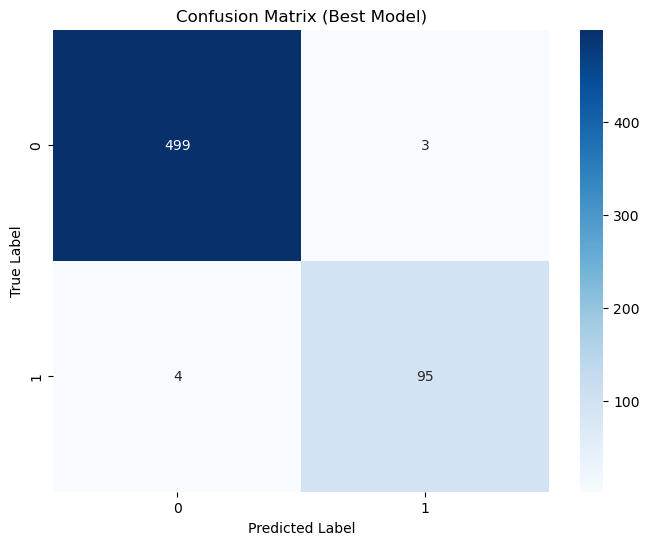

564     datasets/Spam/easy_ham/00815.141d4c82a4df4a06f...
80      datasets/Spam/spam/00490.f0020a3ea5546c122f688...
92      datasets/Spam/spam/00158.9c8bf53ed738031b4bfab...
1164    datasets/Spam/easy_ham/02077.b414e742b034b2ac1...
394     datasets/Spam/spam/00225.b1ca16fa2be1be1d68f5e...
                              ...                        
831     datasets/Spam/easy_ham/00820.13f6cb2d10777d8b8...
197     datasets/Spam/spam/00194.767c323b4ae7a4909397e...
1889    datasets/Spam/easy_ham/00583.7db5166f3ec5a8bcf...
49      datasets/Spam/easy_ham/01467.3c3e579305d1975c1...
2406    datasets/Spam/easy_ham/02224.4f3f70256587197ca...
Name: message_path, Length: 601, dtype: object


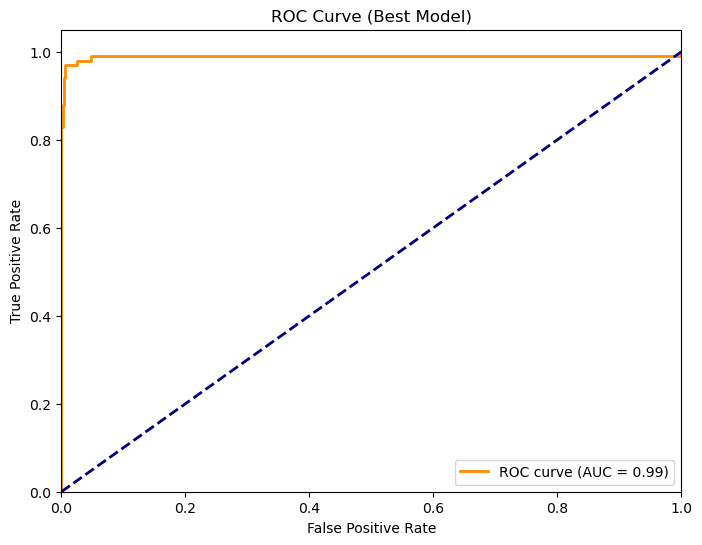

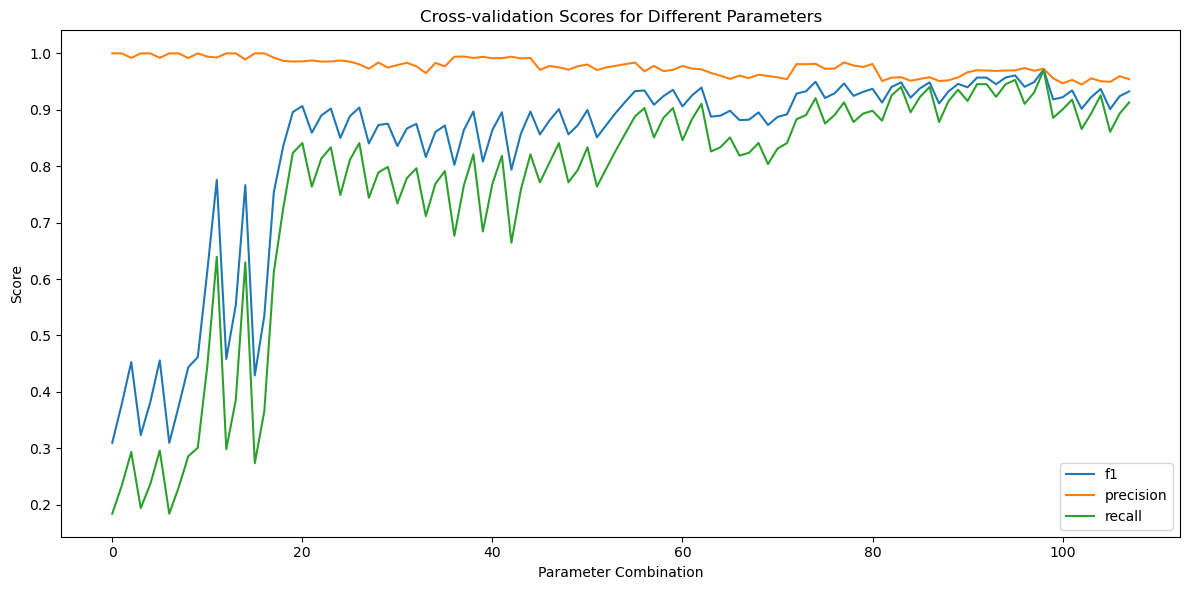

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# Define the parameter grid for GridSearchCV
param_grid = {
    'tokenizer__include_headers': [True, False],
    'word2vec__vector_size': [50, 100, 200],
    'word2vec__window': [3, 5, 7],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__C': [0.1, 1, 10]
}

# Create scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

# Initialize GridSearchCV with our pipeline
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=scoring,
    refit='f1',  # Use F1 score to select the best model
    n_jobs=-1,   # Use all available cores
    verbose=2    # Show progress
)

# Fit the grid search
print("Training models with cross-validation...")
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

# Use the best model for predictions
print("\nMaking predictions with the best model...")
y_pred = grid_search.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Best Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Get probability scores for test set
y_prob = grid_search.predict_proba(X_test)

# Plot ROC curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Best Model)')
plt.legend(loc="lower right")
plt.show()

# Plot cross-validation results
cv_results = pd.DataFrame(grid_search.cv_results_)
scores = ['mean_test_f1', 'mean_test_precision', 'mean_test_recall']
plt.figure(figsize=(12, 6))

for score in scores:
    plt.plot(range(len(cv_results)), cv_results[score], label=score.replace('mean_test_', ''))

plt.title('Cross-validation Scores for Different Parameters')
plt.xlabel('Parameter Combination')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# Learning Curves Analysis
We'll plot learning curves to analyze how the model's performance changes with increasing training data. This helps us:
1. Detect overfitting (if training scores are much higher than validation scores)
2. Determine if more training data would help
3. See if the model has high variance or high bias

Generating learning curves...
[learning_curve] Training set sizes: [ 192  384  576  768  960 1152 1344 1536 1728 1920]
371     datasets/Spam/spam/00309.d9efb4713f45f4e1237d3...
253     datasets/Spam/spam/00053.d88d8b162ca1b7108221f...
300     datasets/Spam/spam/00479.a2cd6780001042d8203b0...
386     datasets/Spam/spam/00132.0ead3e293c6c41cbffb69...
65      datasets/Spam/spam/00441.77768298934252b2fa200...
                              ...                        
187     datasets/Spam/spam/00318.7ce7e3cbbf4fa9c30a67b...
1267    datasets/Spam/easy_ham/00370.0a2e3b397565840b5...
1027    datasets/Spam/easy_ham/02359.63b4bf64205944352...
1850    datasets/Spam/easy_ham/00100.f070e3aaa7f475f95...
1499    datasets/Spam/easy_ham/01050.bb48dfade0a8f3729...
Name: message_path, Length: 192, dtype: object
371     datasets/Spam/spam/00309.d9efb4713f45f4e1237d3...
253     datasets/Spam/spam/00053.d88d8b162ca1b7108221f...
300     datasets/Spam/spam/00479.a2cd6780001042d8203b0...
386     datasets/Spam/

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


71      datasets/Spam/easy_ham/01447.98e4b20ceb192594e...
473     datasets/Spam/spam/00069.066b1a012235d062a5da7...
1753    datasets/Spam/easy_ham/00776.20cdc88a69e453f1e...
268     datasets/Spam/spam/00020.29725cf331fc21e18a180...
1481    datasets/Spam/easy_ham/00659.1217006d88c29f2f9...
                              ...                        
1078    datasets/Spam/easy_ham/01144.b3cbc4db9d2eac4cd...
1377    datasets/Spam/easy_ham/02288.bea4bfd2ffe3c40c4...
2014    datasets/Spam/easy_ham/01659.1d4646886358156ac...
1790    datasets/Spam/easy_ham/00129.ac1318f7fba969847...
1571    datasets/Spam/easy_ham/00970.b567daf8f05ff88b2...
Name: message_path, Length: 481, dtype: object
71      datasets/Spam/easy_ham/01447.98e4b20ceb192594e...
473     datasets/Spam/spam/00069.066b1a012235d062a5da7...
1753    datasets/Spam/easy_ham/00776.20cdc88a69e453f1e...
268     datasets/Spam/spam/00020.29725cf331fc21e18a180...
1481    datasets/Spam/easy_ham/00659.1217006d88c29f2f9...
                         

[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   48.9s finished


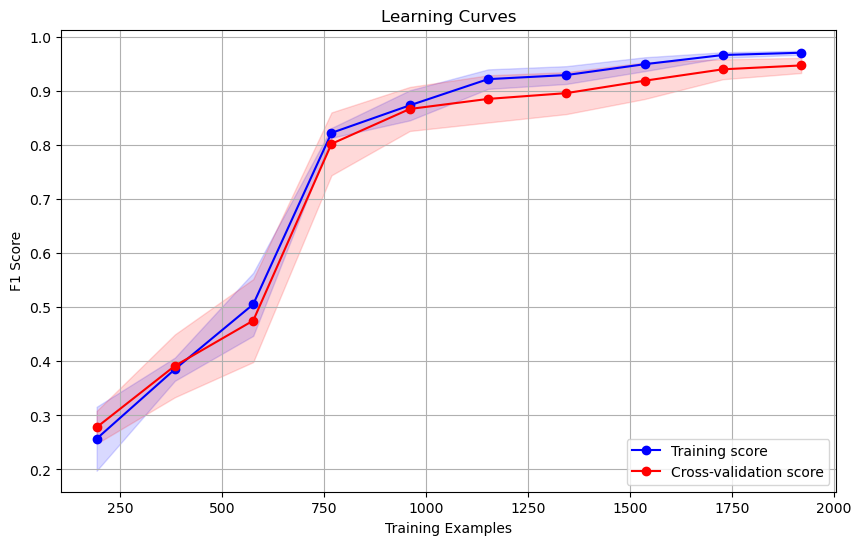

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curves(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=cv,
        n_jobs=-1,
        scoring='f1',
        verbose=1
    )
    
    # Calculate mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot learning curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    
    plt.plot(train_sizes, val_mean, label='Cross-validation score', color='red', marker='o')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
    
    plt.xlabel('Training Examples')
    plt.ylabel('F1 Score')
    plt.title('Learning Curves')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    # Print the final scores
    print(f"Final training score: {train_mean[-1]:.3f} (+/- {train_std[-1]*2:.3f})")
    print(f"Final validation score: {val_mean[-1]:.3f} (+/- {val_std[-1]*2:.3f})")
    
    plt.show()

# Plot learning curves for the best model from GridSearchCV
print("Generating learning curves...")
plot_learning_curves(grid_search.best_estimator_, X_train, y_train)

The main goal of these excercises is to understand the concepts associated with classification, along with the models available to us, and the parameters that we can use to tune them. The code we will learn over time.

For now, we are going to stop here, but I want to come back in the future and test this out with a few other things:
1. what if we remove the headers we deemed as low information, what effect does that have?
2. what if we remove the headers completely, what effect would that have?
3. There is a second data set in the spam folder, with harder examples, what if we run our model against that. What results would we get?